# **0. Import the necessary packages**

In [1]:
#Import libraries for further processing of the BoxOffice data and perform analysis

import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as stats

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score

# **1. Import the boxofficemojo dataset collected using web crawler**

In [2]:
#Import data of BoxOffice

df_boxoffice = pd.read_csv("BoxOffice_Final.csv")

In [3]:
df_boxoffice

,Date,Total_Gross,Top_Movie_Gross,Total_Theaters,Movie_list
0,2022-01-01,40328448.0,23112936.0,31747.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin..."
1,2022-01-02,29916398.0,17502959.0,31746.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin..."
2,2022-01-03,13749958.0,7908732.0,31332.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin..."
3,2022-01-04,10747521.0,5918802.0,31335.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin..."
4,2022-01-05,7649033.0,4383219.0,31332.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin..."
...,...,...,...,...,...
1637,2026-06-26,55236145.0,21444067.0,32441.0,"['Toy Story 5', 'Supergirl', 'Jackass: Best an..."
1638,2026-06-27,55862125.0,27494092.0,32428.0,"['Toy Story 5', 'Supergirl', 'Obsession', 'Dis..."
1639,2026-06-28,43272496.0,21890869.0,32850.0,"['Toy Story 5', 'Supergirl', 'Obsession', 'Dis..."
1640,2026-06-29,17369772.0,8187838.0,32365.0,"['Toy Story 5', 'Supergirl', 'Obsession', 'Dis..."


## 1-1. Aggregate the initial box office dataset on quarterly basis

In [4]:
#Convert the existent date in string to datetime format
df_boxoffice['Date'] = pd.to_datetime(df_boxoffice['Date'])

df_boxoffice['Quarter'] = df_boxoffice['Date'].dt.to_period('Q').astype(str)

In [5]:
#Check if the conversion and addition went well
df_boxoffice.head(10)

#Successful conversion with Quarter column added

,Date,Total_Gross,Top_Movie_Gross,Total_Theaters,Movie_list,Quarter
0,2022-01-01,40328448.0,23112936.0,31747.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin...",2022Q1
1,2022-01-02,29916398.0,17502959.0,31746.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin...",2022Q1
2,2022-01-03,13749958.0,7908732.0,31332.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin...",2022Q1
3,2022-01-04,10747521.0,5918802.0,31335.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin...",2022Q1
4,2022-01-05,7649033.0,4383219.0,31332.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin...",2022Q1
5,2022-01-06,6880434.0,3926778.0,31332.0,"['Spider-Man: No Way Home', 'Sing 2', ""The Kin...",2022Q1
6,2022-01-07,16541251.0,8303811.0,30223.0,"['Spider-Man: No Way Home', 'Sing 2', 'The 355...",2022Q1
7,2022-01-08,28517334.0,14828927.0,30223.0,"['Spider-Man: No Way Home', 'Sing 2', 'The 355...",2022Q1
8,2022-01-09,17604707.0,9485183.0,30223.0,"['Spider-Man: No Way Home', 'Sing 2', 'The 355...",2022Q1
9,2022-01-10,4506612.0,2426248.0,30198.0,"['Spider-Man: No Way Home', 'Sing 2', 'The 355...",2022Q1


In [6]:
#Convert the dataframe into quarter-based records

df_quarterly = df_boxoffice.groupby('Quarter').agg(
    Total_Gross_Quarter = ('Total_Gross', 'sum'),
    Top_Movie_Gross_Quarter = ('Top_Movie_Gross', 'max'),
    Total_Theaters_Quarter = ('Total_Theaters', 'sum'),
    Average_Theaters_Quarter = ('Total_Theaters', 'mean'),
    Gross_Volatility_Quarter = ('Total_Gross', 'std'),
    Movie_Count_Quarter = ('Movie_list', lambda x: len(set(x)))
).reset_index()

df_quarterly['Average_Gross_Per_Theater'] = df_quarterly['Total_Gross_Quarter'] / df_quarterly['Total_Theaters_Quarter']
df_quarterly['BlockBuster_Dominance_Ratio'] = df_quarterly['Top_Movie_Gross_Quarter'] / df_quarterly['Total_Gross_Quarter']


In [7]:
df_quarterly

,Quarter,Total_Gross_Quarter,Top_Movie_Gross_Quarter,Total_Theaters_Quarter,Average_Theaters_Quarter,Gross_Volatility_Quarter,Movie_Count_Quarter,Average_Gross_Per_Theater,BlockBuster_Dominance_Ratio
0,2022Q1,1.335591e+09,56608349.0,2918407.0,32426.744444,1.270772e+07,90,457.643786,0.042384
1,2022Q2,2.319860e+09,90720784.0,2705239.0,29727.901099,2.007074e+07,91,857.543348,0.039106
2,2022Q3,1.916953e+09,69554073.0,3396367.0,36917.032609,1.771591e+07,92,564.412807,0.036284
3,2022Q4,1.768143e+09,84285721.0,2847343.0,30949.380435,1.650998e+07,92,620.979926,0.047669
4,2023Q1,1.707986e+09,46431851.0,2967249.0,32969.433333,1.377492e+07,90,575.612742,0.027185
5,2023Q2,2.671745e+09,56989725.0,2886282.0,31717.384615,1.956464e+07,91,925.670013,0.021331
6,2023Q3,2.640622e+09,70503178.0,3250157.0,35327.793478,2.171553e+07,92,812.459833,0.026699
7,2023Q4,1.840479e+09,39645580.0,3133462.0,34059.369565,1.506711e+07,92,587.362930,0.021541
8,2024Q1,1.595511e+09,36807592.0,3274732.0,35986.065934,1.298123e+07,91,487.218707,0.023069
9,2024Q2,1.931445e+09,63558115.0,3026854.0,33262.131868,1.640116e+07,91,638.103218,0.032907


# **2. Import data from external sources**

## 2-1. Consumer Price Index (CPI) on recreation

In [8]:
#Link: https://fred.stlouisfed.org/series/CPIRECNS , data from Jan 2022 to May 2026
df_CPI = pd.read_csv("CPIRECNS.csv")

#Find out the names of columns
print(df_CPI.columns)

Index(['observation_date', 'CPIRECNS'], dtype='str')


In [9]:
#Transform the observation_date into datetime format
df_CPI['observation_date'] = pd.to_datetime(df_CPI['observation_date'])

df_CPI['Quarter'] = df_CPI['observation_date'].dt.to_period('Q').astype(str)

df_CPI_quarterly = df_CPI.groupby('Quarter').agg(
    CPI_Quarter = ('CPIRECNS', 'mean')
).reset_index()

df_CPI_quarterly

,Quarter,CPI_Quarter
0,2022Q1,128.830000
1,2022Q2,130.309667
2,2022Q3,131.368333
3,2022Q4,132.875667
4,2023Q1,135.096333
5,2023Q2,136.318333
6,2023Q3,136.396667
7,2023Q4,136.609667
8,2024Q1,138.101667
9,2024Q2,138.215000


## 2-2. Disposable Personal Income (DPI) of households

In [10]:
#Link: https://fred.stlouisfed.org/series/DSPIC96 , data from Jan 2022 to May 2026

df_DPI = pd.read_csv('DSPIC96.csv')

print(df_DPI.columns)

Index(['observation_date', 'DSPIC96'], dtype='str')


In [11]:
#Transform the observation_date into datetime format
df_DPI['observation_date'] = pd.to_datetime(df_DPI['observation_date'])

df_DPI['Quarter'] = df_DPI['observation_date'].dt.to_period('Q').astype(str)

df_DPI_quarterly = df_DPI.groupby('Quarter').agg(
    DPI_Quarter = ('DSPIC96', 'mean')
).reset_index()

df_DPI_quarterly

,Quarter,DPI_Quarter
0,2022Q1,16180.300000
1,2022Q2,16097.133333
2,2022Q3,16353.833333
3,2022Q4,16519.066667
4,2023Q1,17001.300000
5,2023Q2,17182.766667
6,2023Q3,17269.366667
7,2023Q4,17416.700000
8,2024Q1,17596.200000
9,2024Q2,17701.000000


## 2-3. Netflix revenue data

In [12]:
#Link: https://ir.netflix.net/financials/quarterly-earnings/default.aspx 
#Using as a lagged variable, so 2022Q1 uses 2021Q4 data as an input, and so on

Netflix_revenues ={
    "2022Q1": 7709318,
    "2022Q2": 7867767,
    "2022Q3": 7970141,
    "2022Q4": 7925589,
    "2023Q1": 7852053,
    "2023Q2": 8161503,
    "2023Q3": 8187301,
    "2023Q4": 8541668,
    "2024Q1": 8832825,
    "2024Q2": 9370440,
    "2024Q3": 9559310,
    "2024Q4": 9824703,
    "2025Q1": 10246513,
    "2025Q2": 10542801,
    "2025Q3": 11079166,
    "2025Q4": 11510307,
    "2026Q1": 12050762,
    "2026Q2": 12249757
}

## 2-4. AMC Revenue data

In [13]:
#Import the revenue data of AMC, which is our dependent variable
#Link: https://investor.amctheatres.com/financial-information/financial-results
#Referring to GAAP results - Total revenues in Earnings Release published for each quarter 

#Anchor value to multiply on the decimals of revenues shown in quarterly reports, for accurate representation of revenue
anchor = 1000000

AMC_revenues = {
    "2022Q1": 785.7,
    "2022Q2": 1166.4,
    "2022Q3": 968.4,
    "2022Q4": 990.9,
    "2023Q1": 954.4,
    "2023Q2": 1347.9,
    "2023Q3": 1405.9,
    "2023Q4": 1104.4,
    "2024Q1": 951.4,
    "2024Q2": 1030.6,
    "2024Q3": 1348.8,
    "2024Q4": 1306.4,
    "2025Q1": 862.5,
    "2025Q2": 1397.9,
    "2025Q3": 1300.2,
    "2025Q4": 1288.3,
    "2026Q1": 1045.4,
    "2026Q2": 0
}

#Substituted 0 into 2026Q2 for avoiding the error when concatenating the data later

#Multiply anchor for each value
AMC_revenues = {k: v * anchor for k,v in AMC_revenues.items()}

# **3. Merge the data into one**

In [14]:
#Make dataframes which take quarter column as an index
df1 = df_quarterly.set_index('Quarter')
df2 = df_CPI_quarterly.set_index('Quarter')
df3 = df_DPI_quarterly.set_index('Quarter')

#Merge!
df_final = pd.concat([df1,df2,df3], axis = 1).reset_index()
df_final

,Quarter,Total_Gross_Quarter,Top_Movie_Gross_Quarter,Total_Theaters_Quarter,Average_Theaters_Quarter,Gross_Volatility_Quarter,Movie_Count_Quarter,Average_Gross_Per_Theater,BlockBuster_Dominance_Ratio,CPI_Quarter,DPI_Quarter
0,2022Q1,1.335591e+09,56608349.0,2918407.0,32426.744444,1.270772e+07,90,457.643786,0.042384,128.830000,16180.300000
1,2022Q2,2.319860e+09,90720784.0,2705239.0,29727.901099,2.007074e+07,91,857.543348,0.039106,130.309667,16097.133333
2,2022Q3,1.916953e+09,69554073.0,3396367.0,36917.032609,1.771591e+07,92,564.412807,0.036284,131.368333,16353.833333
3,2022Q4,1.768143e+09,84285721.0,2847343.0,30949.380435,1.650998e+07,92,620.979926,0.047669,132.875667,16519.066667
4,2023Q1,1.707986e+09,46431851.0,2967249.0,32969.433333,1.377492e+07,90,575.612742,0.027185,135.096333,17001.300000
5,2023Q2,2.671745e+09,56989725.0,2886282.0,31717.384615,1.956464e+07,91,925.670013,0.021331,136.318333,17182.766667
6,2023Q3,2.640622e+09,70503178.0,3250157.0,35327.793478,2.171553e+07,92,812.459833,0.026699,136.396667,17269.366667
7,2023Q4,1.840479e+09,39645580.0,3133462.0,34059.369565,1.506711e+07,92,587.362930,0.021541,136.609667,17416.700000
8,2024Q1,1.595511e+09,36807592.0,3274732.0,35986.065934,1.298123e+07,91,487.218707,0.023069,138.101667,17596.200000
9,2024Q2,1.931445e+09,63558115.0,3026854.0,33262.131868,1.640116e+07,91,638.103218,0.032907,138.215000,17701.000000


In [15]:
df_final['Netflix_Revenue'] = df_final['Quarter'].map(Netflix_revenues)
df_final['AMC_Revenue'] = df_final['Quarter'].map(AMC_revenues)

In [16]:
df_final
#Merging complete!!

,Quarter,Total_Gross_Quarter,Top_Movie_Gross_Quarter,Total_Theaters_Quarter,Average_Theaters_Quarter,Gross_Volatility_Quarter,Movie_Count_Quarter,Average_Gross_Per_Theater,BlockBuster_Dominance_Ratio,CPI_Quarter,DPI_Quarter,Netflix_Revenue,AMC_Revenue
0,2022Q1,1.335591e+09,56608349.0,2918407.0,32426.744444,1.270772e+07,90,457.643786,0.042384,128.830000,16180.300000,7709318,7.857000e+08
1,2022Q2,2.319860e+09,90720784.0,2705239.0,29727.901099,2.007074e+07,91,857.543348,0.039106,130.309667,16097.133333,7867767,1.166400e+09
2,2022Q3,1.916953e+09,69554073.0,3396367.0,36917.032609,1.771591e+07,92,564.412807,0.036284,131.368333,16353.833333,7970141,9.684000e+08
3,2022Q4,1.768143e+09,84285721.0,2847343.0,30949.380435,1.650998e+07,92,620.979926,0.047669,132.875667,16519.066667,7925589,9.909000e+08
4,2023Q1,1.707986e+09,46431851.0,2967249.0,32969.433333,1.377492e+07,90,575.612742,0.027185,135.096333,17001.300000,7852053,9.544000e+08
5,2023Q2,2.671745e+09,56989725.0,2886282.0,31717.384615,1.956464e+07,91,925.670013,0.021331,136.318333,17182.766667,8161503,1.347900e+09
6,2023Q3,2.640622e+09,70503178.0,3250157.0,35327.793478,2.171553e+07,92,812.459833,0.026699,136.396667,17269.366667,8187301,1.405900e+09
7,2023Q4,1.840479e+09,39645580.0,3133462.0,34059.369565,1.506711e+07,92,587.362930,0.021541,136.609667,17416.700000,8541668,1.104400e+09
8,2024Q1,1.595511e+09,36807592.0,3274732.0,35986.065934,1.298123e+07,91,487.218707,0.023069,138.101667,17596.200000,8832825,9.514000e+08
9,2024Q2,1.931445e+09,63558115.0,3026854.0,33262.131868,1.640116e+07,91,638.103218,0.032907,138.215000,17701.000000,9370440,1.030600e+09


# **4. EDA on the dataset**

## 4-1. Plot of AMC revenues

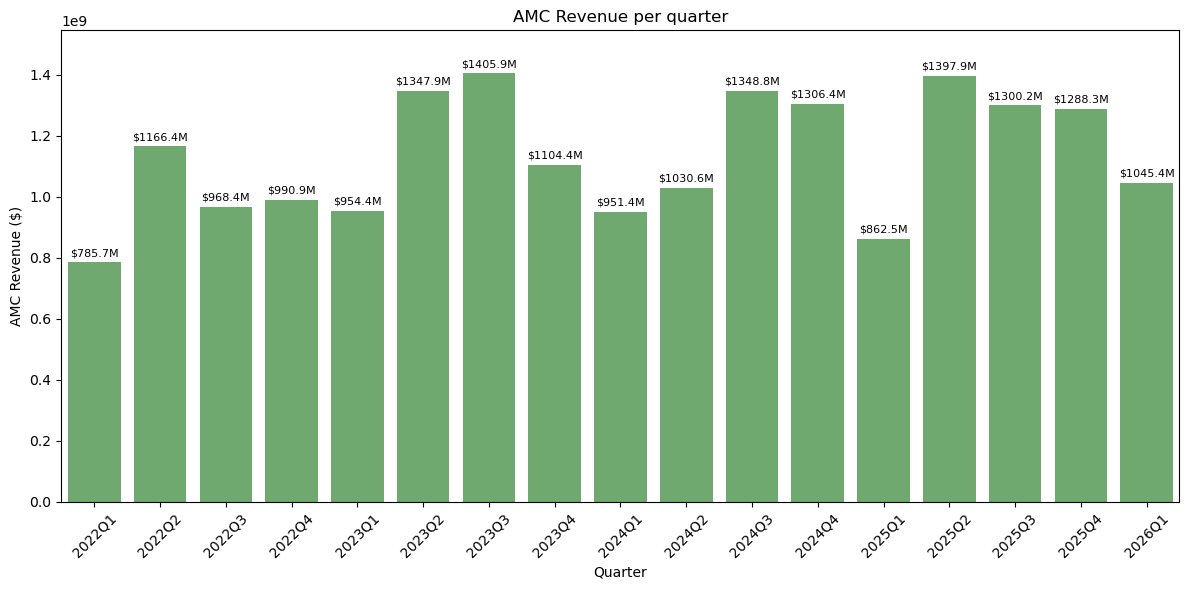

In [17]:
fig1, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=df_final[:-1], x='Quarter', y='AMC_Revenue', ax=ax1, color='green', alpha=0.6)
ax1.set_ylabel('AMC Revenue ($)')
ax1.tick_params(axis='y')
plt.xticks(rotation=45)

#Labelling the total revenue for each quarter
for container in ax1.containers:
    ax1.bar_label(container, fmt=lambda x: f"${x / 1e6:.1f}M", padding=3, fontsize=8)

ax1.set_ylim(0, df_final['AMC_Revenue'].max() * 1.1)

plt.title('AMC Revenue per quarter')
plt.tight_layout()
plt.show()

## 4-2. AMC Revenue vs proxy variables

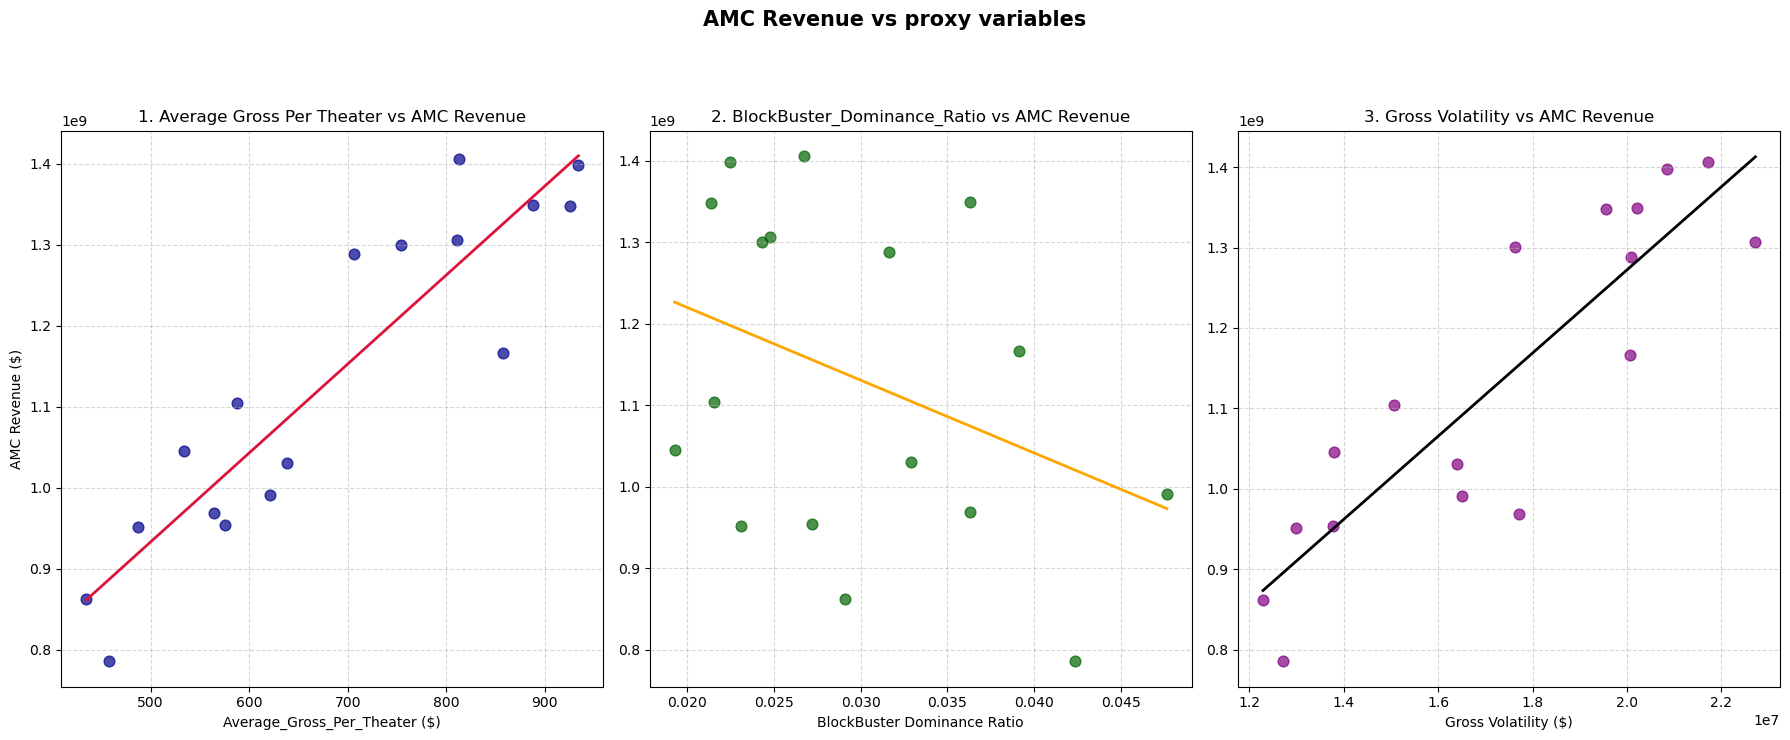

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# 1. Average Gross Per Theater vs AMC Revenue

sns.regplot(
    data=df_final[:-1], x='Average_Gross_Per_Theater', y='AMC_Revenue', ax=axes[0],
    ci= False, scatter_kws={'s': 60, 'color': 'darkblue', 'alpha': 0.7}, 
    line_kws={'color': 'crimson', 'linewidth': 2}
)
axes[0].set_title('1. Average Gross Per Theater vs AMC Revenue', fontsize=12)
axes[0].set_xlabel('Average_Gross_Per_Theater ($)', fontsize=10)
axes[0].set_ylabel('AMC Revenue ($)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)


# 2. BlockBuster Dominance Ratio vs AMC Revenue

sns.regplot(
    data=df_final[:-1], x='BlockBuster_Dominance_Ratio', y='AMC_Revenue', ax=axes[1],
    ci= False, scatter_kws={'s': 60, 'color': 'darkgreen', 'alpha': 0.7}, 
    line_kws={'color': 'orange', 'linewidth': 2}
)
axes[1].set_title('2. BlockBuster_Dominance_Ratio vs AMC Revenue', fontsize=12)
axes[1].set_xlabel('BlockBuster Dominance Ratio', fontsize=10)
axes[1].set_ylabel('')
axes[1].grid(True, linestyle='--', alpha=0.5)


# 3. Gross Volatility vs AMC Revenue

sns.regplot(
    data=df_final[:-1], x='Gross_Volatility_Quarter', y='AMC_Revenue', ax=axes[2],
    ci= False, scatter_kws={'s': 60, 'color': 'purple', 'alpha': 0.7}, 
    line_kws={'color': 'black', 'linewidth': 2}
)
axes[2].set_title('3. Gross Volatility vs AMC Revenue', fontsize=12)
axes[2].set_xlabel('Gross Volatility ($)', fontsize=10)
axes[2].set_ylabel('')
axes[2].grid(True, linestyle='--', alpha=0.5)

#Layout edit
plt.suptitle('AMC Revenue vs proxy variables', fontsize=15, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 4-3. CPI, DPI vs AMC revenue

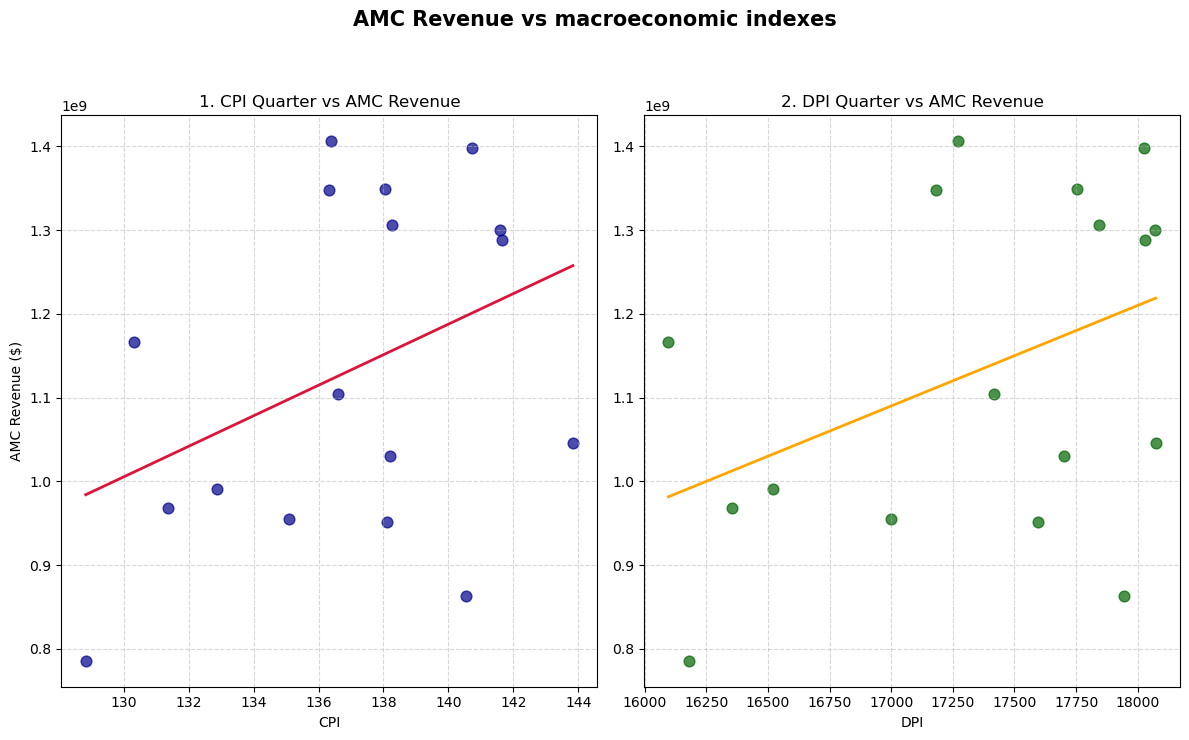

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# 1. CPI vs AMC Revenue

sns.regplot(
    data=df_final[:-1], x='CPI_Quarter', y='AMC_Revenue', ax=axes[0],
    ci= False, scatter_kws={'s': 60, 'color': 'darkblue', 'alpha': 0.7}, 
    line_kws={'color': 'crimson', 'linewidth': 2}
)
axes[0].set_title('1. CPI Quarter vs AMC Revenue', fontsize=12)
axes[0].set_xlabel('CPI', fontsize=10)
axes[0].set_ylabel('AMC Revenue ($)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)


# 2. DPI vs AMC Revenue

sns.regplot(
    data=df_final[:-1], x='DPI_Quarter', y='AMC_Revenue', ax=axes[1],
    ci= False, scatter_kws={'s': 60, 'color': 'darkgreen', 'alpha': 0.7}, 
    line_kws={'color': 'orange', 'linewidth': 2}
)
axes[1].set_title('2. DPI Quarter vs AMC Revenue', fontsize=12)
axes[1].set_xlabel('DPI', fontsize=10)
axes[1].set_ylabel('')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('AMC Revenue vs macroeconomic indexes', fontsize=15, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 4-4. Netflix vs AMC in terms of revenue

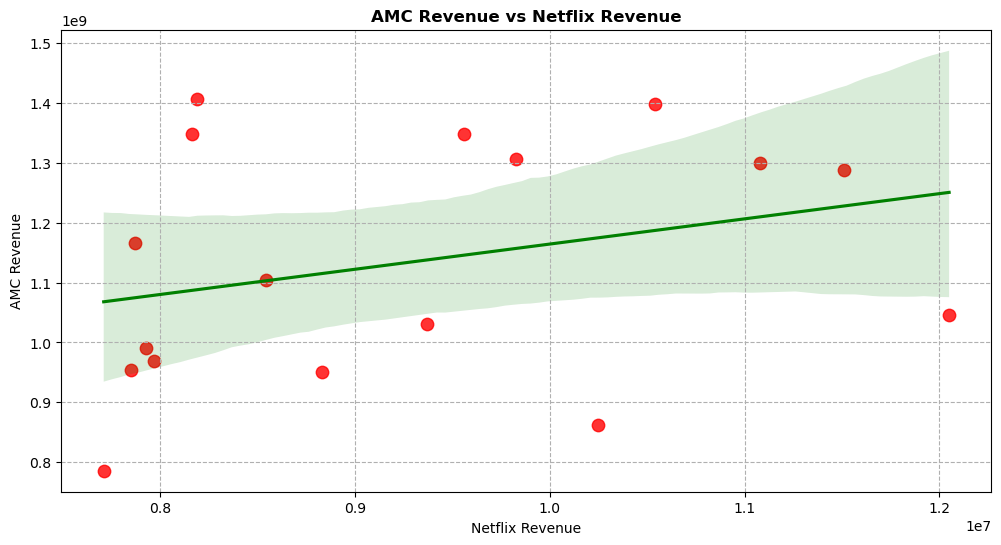

In [20]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df_final[:-1], x='Netflix_Revenue', y='AMC_Revenue', 
            scatter_kws={'s':80, 'color':'red'}, line_kws={'color':'green'})
plt.title('AMC Revenue vs Netflix Revenue', weight = 'bold')
plt.xlabel('Netflix Revenue')
plt.ylabel('AMC Revenue')
plt.grid(True, linestyle='--')
plt.show()

## 4-4. Correlation between variables

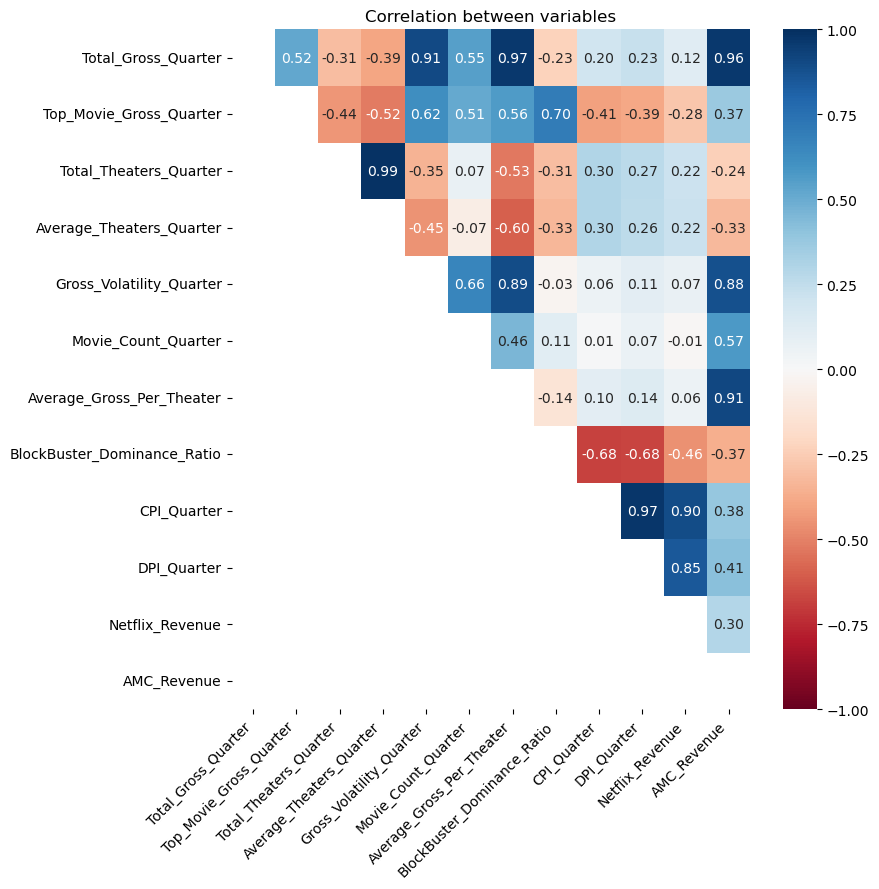

In [21]:
#Correlation matrix of variables
df_corr = df_final.iloc[:-1,1:].corr()

plt.figure(figsize=(9,9))
mask = np.tril(np.ones_like(df_corr, dtype=bool))
sns.heatmap(df_corr, annot=True, mask=mask,fmt=".2f", cmap='RdBu', vmin=-1, vmax=1)
plt.title('Correlation between variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **5. Model Building**

## 5-1. Split the data based on the type of variables

In [ ]:
#Separate between independent and dependent variables
#Exclude 2026Q2 data as it is the final data point to be tested
df_x, df_y = df_final.iloc[:-1,1:-1], df_final.iloc[:-1,-1]

In [23]:
df_x

,Total_Gross_Quarter,Top_Movie_Gross_Quarter,Total_Theaters_Quarter,Average_Theaters_Quarter,Gross_Volatility_Quarter,Movie_Count_Quarter,Average_Gross_Per_Theater,BlockBuster_Dominance_Ratio,CPI_Quarter,DPI_Quarter,Netflix_Revenue
0,1.335591e+09,56608349.0,2918407.0,32426.744444,1.270772e+07,90,457.643786,0.042384,128.830000,16180.300000,7709318
1,2.319860e+09,90720784.0,2705239.0,29727.901099,2.007074e+07,91,857.543348,0.039106,130.309667,16097.133333,7867767
2,1.916953e+09,69554073.0,3396367.0,36917.032609,1.771591e+07,92,564.412807,0.036284,131.368333,16353.833333,7970141
3,1.768143e+09,84285721.0,2847343.0,30949.380435,1.650998e+07,92,620.979926,0.047669,132.875667,16519.066667,7925589
4,1.707986e+09,46431851.0,2967249.0,32969.433333,1.377492e+07,90,575.612742,0.027185,135.096333,17001.300000,7852053
5,2.671745e+09,56989725.0,2886282.0,31717.384615,1.956464e+07,91,925.670013,0.021331,136.318333,17182.766667,8161503
6,2.640622e+09,70503178.0,3250157.0,35327.793478,2.171553e+07,92,812.459833,0.026699,136.396667,17269.366667,8187301
7,1.840479e+09,39645580.0,3133462.0,34059.369565,1.506711e+07,92,587.362930,0.021541,136.609667,17416.700000,8541668
8,1.595511e+09,36807592.0,3274732.0,35986.065934,1.298123e+07,91,487.218707,0.023069,138.101667,17596.200000,8832825
9,1.931445e+09,63558115.0,3026854.0,33262.131868,1.640116e+07,91,638.103218,0.032907,138.215000,17701.000000,9370440


In [24]:
df_y

0     7.857000e+08
1     1.166400e+09
2     9.684000e+08
3     9.909000e+08
4     9.544000e+08
5     1.347900e+09
6     1.405900e+09
7     1.104400e+09
8     9.514000e+08
9     1.030600e+09
10    1.348800e+09
11    1.306400e+09
12    8.625000e+08
13    1.397900e+09
14    1.300200e+09
15    1.288300e+09
16    1.045400e+09
Name: AMC_Revenue, dtype: float64

## 5-2. Pick the independent variables that can explain the dependent variable well, and not correlated to other variables

In [25]:
#Pre-define a model to be used to extract the columns we will use
LinReg = skl.linear_model.LinearRegression()

#Case 1: Modelling with 3 variables
feature_selector = skl.feature_selection.RFE(estimator=LinReg, n_features_to_select=3, step=1)
feature_selector.fit(df_x,df_y)

selected_columns = df_x.columns[feature_selector.support_]
print(f"Selected 3 features: {selected_columns}")

#Case 2: Modelling with 4 variables
feature_selector2 = skl.feature_selection.RFE(estimator=LinReg, n_features_to_select=4, step=1)
feature_selector2.fit(df_x,df_y)

selected_columns2 = df_x.columns[feature_selector2.support_]
print(f"Selected 4 features: {selected_columns2}")

Selected 3 features: Index(['Movie_Count_Quarter', 'BlockBuster_Dominance_Ratio', 'CPI_Quarter'], dtype='str')
Selected 4 features: Index(['Movie_Count_Quarter', 'Average_Gross_Per_Theater',
       'BlockBuster_Dominance_Ratio', 'CPI_Quarter'],
      dtype='str')


In [ ]:
#Create a weight for each data entries
#Past data holds smaller weight, and more recent entries take bigger weight, as recent performance and revenue tells more about 2026Q2 performances

alpha = 0.1

time_steps = np.arange(len(df_x))

weights = (1-alpha) ** (len(df_x) - 1 - time_steps)
#Normalise the weight
weights = weights * (len(df_x)/np.sum(weights))


In [27]:
weights

array([0.37806382, 0.42007091, 0.46674546, 0.51860607, 0.57622896,
       0.6402544 , 0.71139378, 0.79043754, 0.87826393, 0.97584881,
       1.08427645, 1.20475162, 1.33861291, 1.48734767, 1.65260853,
       1.8362317 , 2.04025744])

### 5-2-1. Use 3 variables to train and test model

In [28]:
##Filter out the columns
X1 = df_x[selected_columns]
#Add constant on to training dataset to be used in statsmodels' linear regression
X1_constant = stats.add_constant(X1)

#Implement LOOCV to train all data except 1 into a model, and validate using the one left out
LOOCV1 = LeaveOneOut()

#To store the values from the tests for comparison
y1_true = []
y1_pred = []

for train_idx, test_idx in LOOCV1.split(X1_constant):

    X_train, y_train = X1_constant.iloc[train_idx], df_y[train_idx]
    X_test, y_test = X1_constant.iloc[test_idx], df_y[test_idx]

    weights_temp = weights[train_idx]

    model1 = stats.WLS(y_train, X_train, weights= weights_temp)
    trained_model1 = model1.fit()

    pred = trained_model1.predict(X_test)

    y1_true.append(y_test.values[0]) 
    y1_pred.append(pred)

RMSE1 = np.sqrt(mean_squared_error(y1_true, y1_pred))
R2_Score1 = r2_score(y1_true, y1_pred)

print(f"RMSE for model with variables {list(selected_columns)} is:{RMSE1:.2f}")
print(f"R2 score for model with variables {list(selected_columns)} is:{R2_Score1:.2f}")

RMSE for model with variables ['Movie_Count_Quarter', 'BlockBuster_Dominance_Ratio', 'CPI_Quarter'] is:165924335.26
R2 score for model with variables ['Movie_Count_Quarter', 'BlockBuster_Dominance_Ratio', 'CPI_Quarter'] is:0.28


#### 5-2-1-1. Use the whole dataset on the model, to evaluate overall model performance

In [29]:
#This model will take in all of the data rows without LOOCV
model1 = stats.WLS(df_y, X1_constant, weights=weights)
trained_model1 = model1.fit()

trained_model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:            AMC_Revenue   R-squared:                       0.565
Model:                            WLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                     5.621
Date:                Mon, 13 Jul 2026   Prob (F-statistic):             0.0108
Time:                        10:01:46   Log-Likelihood:                -341.86
No. Observations:                  17   AIC:                             691.7
Df Residuals:                      13   BIC:                             695.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                       -1.504e+10   4.25e+09     -3.543      0.004   -2.42e+10   -5.87e+09
Movie_Count_Quarter          1.669e+08   4.26e+07      3.915      0.002    7.48e+07    2.59e+08
BlockBuster_Dominance_Ratio -7.664e+09   6.44e+09     -1.190      0.255   -2.16e+10    6.25e+09
CPI_Quarter                  8.565e+06    1.2e+07      0.714      0.488   -1.73e+07    3.45e+07
==============================================================================
Omnibus:                        0.452   Durbin-Watson:                   2.103
Prob(Omnibus):                  0.798   Jarque-Bera (JB):                0.508
Skew:                           0.314   Prob(JB):                        0.776
Kurtosis:                       2.431   Cond. No.                     3.15e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.15e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### 5-2-2. Use 4 variables to train and test model

In [30]:
##Filter out the columns
X2 = df_x[selected_columns2]
#Add constant on to training dataset to be used in statsmodels' linear regression
X2_constant = stats.add_constant(X2)

#Implement LOOCV to train all data except 1 into a model, and validate using the one left out
LOOCV2 = LeaveOneOut()

#To store the values from the tests for comparison
y2_true = []
y2_pred = []

for train_idx, test_idx in LOOCV2.split(X2_constant):

    X_train, y_train = X2_constant.iloc[train_idx], df_y[train_idx]
    X_test, y_test = X2_constant.iloc[test_idx], df_y[test_idx]

    weights_temp = weights[train_idx]

    model2 = stats.WLS(y_train, X_train, weights= weights_temp)
    trained_model2 = model2.fit()

    pred = trained_model2.predict(X_test)

    y2_true.append(y_test.values[0]) 
    y2_pred.append(pred)

RMSE2 = np.sqrt(mean_squared_error(y2_true, y2_pred))
R2_Score2 = r2_score(y2_true, y2_pred)

print(f"RMSE for model with variables {list(selected_columns2)} is: \n{RMSE2:.2f}")
print(f"R2 score for model with variables {list(selected_columns2)} is: \n{R2_Score2:.2f}")

RMSE for model with variables ['Movie_Count_Quarter', 'Average_Gross_Per_Theater', 'BlockBuster_Dominance_Ratio', 'CPI_Quarter'] is: 
48304411.33
R2 score for model with variables ['Movie_Count_Quarter', 'Average_Gross_Per_Theater', 'BlockBuster_Dominance_Ratio', 'CPI_Quarter'] is: 
0.94


#### 5-2-2-1. Use the whole dataset on the model, to evaluate overall model performance

In [31]:
#This model will take in all of the data rows without LOOCV
model2 = stats.WLS(df_y, X2_constant, weights=weights)
trained_model2 = model2.fit()

trained_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:            AMC_Revenue   R-squared:                       0.969
Model:                            WLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     95.06
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           5.59e-09
Time:                        10:01:46   Log-Likelihood:                -319.29
No. Observations:                  17   AIC:                             648.6
Df Residuals:                      12   BIC:                             652.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                        -6.81e+09   1.34e+09     -5.077      0.000   -9.73e+09   -3.89e+09
Movie_Count_Quarter          6.376e+07   1.43e+07      4.448      0.001    3.25e+07     9.5e+07
Average_Gross_Per_Theater    9.022e+05   7.16e+04     12.600      0.000    7.46e+05    1.06e+06
BlockBuster_Dominance_Ratio  -3.08e+09   1.81e+09     -1.697      0.115   -7.03e+09    8.73e+08
CPI_Quarter                  1.169e+07   3.32e+06      3.524      0.004    4.46e+06    1.89e+07
==============================================================================
Omnibus:                        8.358   Durbin-Watson:                   1.719
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                5.260
Skew:                           1.234   Prob(JB):                       0.0721
Kurtosis:                       4.154   Cond. No.                     1.40e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.4e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### 5-2-3. Try out once more, with the variables with low p-values only from the last summary

In [32]:
cols = ['Movie_Count_Quarter', 'Average_Gross_Per_Theater', 'CPI_Quarter']

##Filter out the columns
X = df_x[cols]
#Add constant on to training dataset to be used in statsmodels' linear regression
X_constant = stats.add_constant(X)

#Implement LOOCV to train all data except 1 into a model, and validate using the one left out
LOOCV = LeaveOneOut()

#To store the values from the tests for comparison
y_true = []
y_pred = []

for train_idx, test_idx in LOOCV.split(X_constant):

    X_train, y_train = X_constant.iloc[train_idx], df_y[train_idx]
    X_test, y_test = X_constant.iloc[test_idx], df_y[test_idx]

    weights_temp = weights[train_idx]

    model = stats.WLS(y_train, X_train, weights= weights_temp)
    trained_model = model.fit()

    pred = trained_model.predict(X_test)

    y_true.append(y_test.values[0]) 
    y_pred.append(pred)

RMSE = np.sqrt(mean_squared_error(y_true, y_pred))
R2_Score = r2_score(y_true, y_pred)

print(f"RMSE for model with variables {cols} is:{RMSE:.2f}")
print(f"R2 score for model with variables {cols} is:{R2_Score:.2f}")

RMSE for model with variables ['Movie_Count_Quarter', 'Average_Gross_Per_Theater', 'CPI_Quarter'] is:50028914.44
R2 score for model with variables ['Movie_Count_Quarter', 'Average_Gross_Per_Theater', 'CPI_Quarter'] is:0.93


#### 5-2-3-1. Use the whole dataset on the model, to evaluate overall model performance

In [33]:
model = stats.WLS(df_y, X_constant, weights=weights)
trained_model = model.fit()

trained_model.summary()
#The model is statistically significant and reliable

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:            AMC_Revenue   R-squared:                       0.962
Model:                            WLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     109.9
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           1.74e-09
Time:                        10:01:46   Log-Likelihood:                -321.12
No. Observations:                  17   AIC:                             650.2
Df Residuals:                      13   BIC:                             653.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                      -6.75e+09   1.43e+09     -4.705      0.000   -9.85e+09   -3.65e+09
Movie_Count_Quarter        5.678e+07   1.47e+07      3.865      0.002     2.5e+07    8.85e+07
Average_Gross_Per_Theater  9.265e+05   7.51e+04     12.345      0.000    7.64e+05    1.09e+06
CPI_Quarter                 1.51e+07   2.82e+06      5.349      0.000       9e+06    2.12e+07
==============================================================================
Omnibus:                        5.812   Durbin-Watson:                   1.337
Prob(Omnibus):                  0.055   Jarque-Bera (JB):                3.069
Skew:                           0.789   Prob(JB):                        0.216
Kurtosis:                       4.358   Cond. No.                     1.03e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.03e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 5-3. Compute the estimated revenue of AMC in 2026 Q2

In [34]:
#Call 2026Q2 data for the model input
X_test_final = df_final[cols].iloc[[-1]]
X_test_final_const = stats.add_constant(X_test_final, has_constant='add')

#Make a prediction on 2026Q2
pred_final = trained_model.predict(X_test_final_const)

print(f"The estimated revenue of AMC in 2026 Q2 is: ${pred_final.values[0]:.2f}")

The estimated revenue of AMC in 2026 Q2 is: $1542539675.99
